# # Electricity Demand Forecasting

This notebook trains and evaluates forecasting models using the
feature-engineered daily electricity-demand dataset.

The objective is to determine whether machine-learning models can improve
forecasting performance compared with a simple historical baseline.

The evaluation follows a chronological time-series split to prevent
future-data leakage.

In [407]:
import pandas as pd 
model_df = pd.read_parquet(
    "../data/features/daily_model_features.parquet"
)
model_df.head()

,date,daily_kwh,day_of_week,month,days_of_week_sin,days_of_week_cos,month_sin,month_cos,lag_1,lag_2,lag_3,lag_7,rolling_mean_7
0,2011-12-21,266.697,2,12,0.974928,-0.222521,-2.449294e-16,1.0,281.951999,271.313000,285.852000,268.984000,270.033000
1,2011-12-22,220.936,3,12,0.433884,-0.900969,-2.449294e-16,1.0,266.697000,281.951999,271.313000,273.415001,269.706286
2,2011-12-23,224.914,4,12,-0.433884,-0.900969,-2.449294e-16,1.0,220.936000,266.697000,281.951999,262.446000,262.209285
3,2011-12-24,225.996,5,12,-0.974928,-0.222521,-2.449294e-16,1.0,224.914000,220.936000,266.697000,246.269000,256.847571
4,2011-12-25,225.718,6,12,-0.781831,0.623490,-2.449294e-16,1.0,225.996000,224.914000,220.936000,285.852000,253.951428


In [408]:
model_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              800 non-null    datetime64[us]
 1   daily_kwh         800 non-null    float64       
 2   day_of_week       800 non-null    int32         
 3   month             800 non-null    int32         
 4   days_of_week_sin  800 non-null    float64       
 5   days_of_week_cos  800 non-null    float64       
 6   month_sin         800 non-null    float64       
 7   month_cos         800 non-null    float64       
 8   lag_1             800 non-null    float64       
 9   lag_2             800 non-null    float64       
 10  lag_3             800 non-null    float64       
 11  lag_7             800 non-null    float64       
 12  rolling_mean_7    800 non-null    float64       
dtypes: datetime64[us](1), float64(10), int32(2)
memory usage: 75.1 KB


In [409]:
model_df.shape


(800, 13)

In [410]:
model_df.columns.to_list()

['date',
 'daily_kwh',
 'day_of_week',
 'month',
 'days_of_week_sin',
 'days_of_week_cos',
 'month_sin',
 'month_cos',
 'lag_1',
 'lag_2',
 'lag_3',
 'lag_7',
 'rolling_mean_7']

## Define target and features
### first real modeling decision: separate the target from the predictors.

In [411]:
target="daily_kwh"


features=[
 'day_of_week',
 'month',
 'days_of_week_sin',
 'days_of_week_cos',
 'month_sin',
 'month_cos',
 'lag_1',
 'lag_2',
 'lag_3',
 'lag_7',
 'rolling_mean_7']

date is intentionally excluded.

Why?

daily_kwh → what we predict

date → used to preserve chronological order / split the data

everything in features → information available to the forecasting model

Then verify:

In [412]:
X = model_df[features]
y = model_df[target]

print("X_shape:",X.shape)
print("y_shape:",y.shape)

X_shape: (800, 11)
y_shape: (800,)


In [413]:
# Define the split index (e.g., 80% train, 20% validation)
split_idx = int(len(model_df) * 0.8)

In [414]:
x_train=X.iloc[:split_idx]
y_train = y.iloc[:split_idx]

x_test=X.iloc[split_idx:]
y_test=y.iloc[split_idx:]

# we cannot do splitting with  random train test split  as # 3. Apply the train-test split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, 
#     y, 
#     test_size=0.20,      # 20% goes to testing, 80% to training
#     random_state=42,     # Fixed seed for consistency
#     stratify=y           # Preserves the 70/30 class distribution in both splits
# ) so we use chronological split above
 

# and verify its shape
print("original_X:",X.shape)
print("original_y:",y.shape)
print("X_train:", x_train.shape)
print("X_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)



original_X: (800, 11)
original_y: (800,)
X_train: (640, 11)
X_test: (160, 11)
y_train: (640,)
y_test: (160,)


One more important verification

We also want to know the actual date boundary with min and max date 

In [415]:
print("Training period :",model_df.iloc[:split_idx]["date"].min()
       ,"to " , model_df.iloc[:split_idx]["date"].max())

print("testing period:", model_df.iloc[split_idx:]["date"].min(),
      "to", model_df.iloc[split_idx:]["date"].max())

Training period : 2011-12-21 00:00:00 to  2013-09-20 00:00:00
testing period: 2013-09-21 00:00:00 to 2014-02-27 00:00:00


A baseline example is a starting point or standard measurement used to compare future results.
### Build the baseline

Before using XGBoost or any sophisticated model, we need to establish:

How well can we predict demand using a very simple rule?

Our first baseline will be:

Naive previous-day forecast

For each test day:

Tomorrow's demand = today's demand

In our existing feature set, that's simply the lag_1 value.

In [416]:
baseline_pred = x_test["lag_1"]

In [417]:

from sklearn.metrics import mean_absolute_error
baseline_mae = mean_absolute_error(y_test,baseline_pred)

baseline_mae

print("Baseline MAE:", baseline_mae)

Baseline MAE: 18.035143793125002


If the baseline MAE is, for example, 50, it means the naive forecast is off by about 50 kWh per day on average on this test period.

We need this number because later we'll ask:

Does XGBoost actually beat 50 kWh/day?

## That means the simple rule:

“Tomorrow ≈ today”

is off by about 18.04 kWh/day on average on the unseen test period.

This is important because XGBoost does not automatically count as an improvement. It has to beat this baseline.

# Establish the baseline properly

Before training XGBoost, calculate RMSE too. This gives us a second view that penalizes large forecasting errors more heavily.

In [418]:
from sklearn.metrics import mean_squared_error
import numpy as np

baseline_rmse = np.sqrt(
    mean_squared_error(y_test, baseline_pred)
)

print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE: 18.035143793125002
Baseline RMSE: 24.186684859893454


In [419]:
print("zero values in y_test :",(y_test==0).sum())

zero values in y_test : 0


Naive baseline

Today's demand → Tomorrow's prediction
        
        ↓

   MAE / RMSE

              VS

XGBoost

Calendar + lags + rolling statistics

        ↓

   MAE / RMSE

In [420]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import mean_absolute_error,root_mean_squared_error
# Import XGBoost (Make sure to run: pip install xgboost)
from xgboost import XGBRegressor

xgb_model=XGBRegressor(random_state=42)
xgb_model.fit(x_train,y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [421]:
y_xgb_Pred=xgb_model.predict(x_test)

xgb_mae=mean_absolute_error(y_test,y_xgb_Pred)
xgb_rmse=np.sqrt(mean_squared_error(y_test,y_xgb_Pred))

print(f"XGBoost MAE:  {xgb_mae:.4f}")
print(f"XGBoost RMSE: {xgb_rmse:.4f}")

XGBoost MAE:  22.2389
XGBoost RMSE: 28.6335


A simple previous-day demand baseline outperformed the initial XGBoost model on the chronological test period, demonstrating that model complexity does not automatically improve forecasting performance.

That's a good engineering finding, not a failure.

Is the model actually using the lag features that EDA told us were strong?

[0.00552736 0.00457851 0.00635486 0.00515762 0.00728797 0.01313089
 0.87012887 0.00599953 0.01472152 0.01017169 0.05694111]


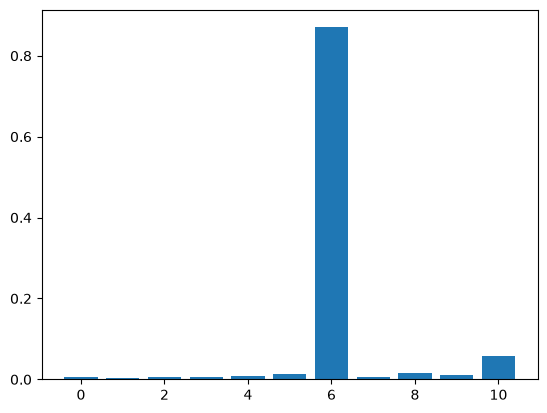

In [422]:
import matplotlib.pyplot as plt
print(xgb_model.feature_importances_)
plt.bar(range(len(xgb_model.feature_importances_)), xgb_model.feature_importances_)
plt.show()

In [423]:
feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=features
).sort_values(ascending=False)   #sort by values only ""

feature_importance



lag_1               0.870129
rolling_mean_7      0.056941
lag_3               0.014722
month_cos           0.013131
lag_7               0.010172
month_sin           0.007288
days_of_week_sin    0.006355
lag_2               0.006000
day_of_week         0.005527
days_of_week_cos    0.005158
month               0.004579
dtype: float32

XGBoost with only the strongest features.We'll test whether the extra calendar features are actually hurting the model.Why these five?

lag_1 → strongest signal
rolling_mean_7 → recent demand level
lag_2, lag_3 → short-term persistence
lag_7 → weekly pattern

Then compare:

Full XGBoost vs Reduced XGBoost vs Naive baseline

In [424]:
target="daily_kwh"


features=[
 
 'lag_1',
 'lag_2',
 'lag_3',
 'lag_7',
 'rolling_mean_7']

X = model_df[features]
y = model_df[target]

print("X_shape:",X.shape)
print("y_shape:",y.shape)

# Define the split index (e.g., 80% train, 20% validation)
split_idx = int(len(model_df) * 0.8)

x_train=X.iloc[:split_idx]
y_train = y.iloc[:split_idx]

x_test=X.iloc[split_idx:]
y_test=y.iloc[split_idx:]

# we cannot do splitting with  random train test split  as # 3. Apply the train-test split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, 
#     y, 
#     test_size=0.20,      # 20% goes to testing, 80% to training
#     random_state=42,     # Fixed seed for consistency
#     stratify=y           # Preserves the 70/30 class distribution in both splits
# ) so we use chronological split above
 

# and verify its shape
print("original_X:",X.shape)
print("original_y:",y.shape)
print("X_train:", x_train.shape)
print("X_test:", x_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

print("Training period :",model_df.iloc[:split_idx]["date"].min()
       ,"to " , model_df.iloc[:split_idx]["date"].max())

print("testing period:", model_df.iloc[split_idx:]["date"].min(),
      "to", model_df.iloc[split_idx:]["date"].max())


X_shape: (800, 5)
y_shape: (800,)
original_X: (800, 5)
original_y: (800,)
X_train: (640, 5)
X_test: (160, 5)
y_train: (640,)
y_test: (160,)
Training period : 2011-12-21 00:00:00 to  2013-09-20 00:00:00
testing period: 2013-09-21 00:00:00 to 2014-02-27 00:00:00


In [425]:
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import mean_absolute_error,root_mean_squared_error
# Import XGBoost (Make sure to run: pip install xgboost)
from xgboost import XGBRegressor

xgb_model=XGBRegressor(random_state=42)
xgb_model.fit(x_train,y_train)

y_xgb_Pred=xgb_model.predict(x_test)

xgb_mae=mean_absolute_error(y_test,y_xgb_Pred)
xgb_rmse=np.sqrt(mean_squared_error(y_test,y_xgb_Pred))

print(f"XGBoost MAE:  {xgb_mae:.4f}")
print(f"XGBoost RMSE: {xgb_rmse:.4f}")

XGBoost MAE:  21.2990
XGBoost RMSE: 28.8871


In [426]:
feature_importance = pd.Series(
    xgb_model.feature_importances_,
    index=features
).sort_values(ascending=False) 
 #sort by values only 

feature_importance

lag_1             0.877252
rolling_mean_7    0.080656
lag_7             0.017817
lag_3             0.013336
lag_2             0.010940
dtype: float32

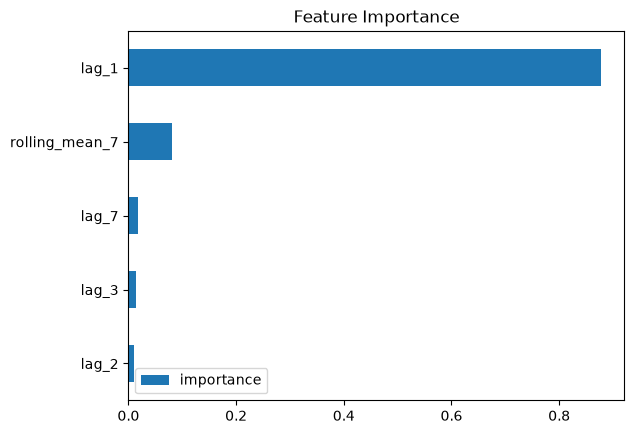

In [427]:
fi = pd.DataFrame(data=xgb_model.feature_importances_,
             index=xgb_model.feature_names_in_,
             columns=['importance'])
fi.sort_values('importance').plot(kind='barh', title='Feature Importance')
plt.show()


experiment results
Model	MAE ↓	RMSE ↓

Naive — lag_1	18.0351	                   24.1867

XGBoost — 11 features	22.2389	         28.6335

XGBoost — 5 features	21.2990	           28.8871

Naive baseline still wins.

The reduced XGBoost improves MAE from 22.24 → 21.30, but it is still 3.26 kWh/day worse than the naive baseline.

Is the problem that XGBoost needs better forecasting features, or is the naive baseline genuinely difficult to beat?

### Next step: analyze the forecast errors

We should look at where the naive baseline makes mistakes.

Why?

If the biggest errors occur during particular months, days, or unusual demand changes, that tells us what information our model is missing.


In [428]:
import pandas as pd 
model_df = pd.read_parquet(
    "../data/features/daily_model_features.parquet"
)
model_df.head()


,date,daily_kwh,day_of_week,month,days_of_week_sin,days_of_week_cos,month_sin,month_cos,lag_1,lag_2,lag_3,lag_7,rolling_mean_7
0,2011-12-21,266.697,2,12,0.974928,-0.222521,-2.449294e-16,1.0,281.951999,271.313000,285.852000,268.984000,270.033000
1,2011-12-22,220.936,3,12,0.433884,-0.900969,-2.449294e-16,1.0,266.697000,281.951999,271.313000,273.415001,269.706286
2,2011-12-23,224.914,4,12,-0.433884,-0.900969,-2.449294e-16,1.0,220.936000,266.697000,281.951999,262.446000,262.209285
3,2011-12-24,225.996,5,12,-0.974928,-0.222521,-2.449294e-16,1.0,224.914000,220.936000,266.697000,246.269000,256.847571
4,2011-12-25,225.718,6,12,-0.781831,0.623490,-2.449294e-16,1.0,225.996000,224.914000,220.936000,285.852000,253.951428


In [429]:
print("y_test:", y_test.shape)

y_test: (160,)


In [430]:

import pandas as pd
# Create the error analysis DataFrame for the naive baseline
# Create the error analysis DataFrame for the naive baseline
df_errors = pd.DataFrame({
    "date": model_df.loc[y_test.index, "date"].to_numpy(),
    "actual": y_test.to_numpy(),
    "naive_prediction": baseline_pred.to_numpy(),
})

df_errors["error"] = df_errors["actual"] - df_errors["naive_prediction"]
df_errors["absolute_error"] = df_errors["error"].abs()

top_10_error = (
    df_errors
    .sort_values(by="absolute_error", ascending=False)
    .head(10)
)
top_10_error



,date,actual,naive_prediction,error,absolute_error
95,2013-12-25,422.718001,323.034000,99.684001,99.684001
127,2014-01-26,431.469000,342.291001,89.177999,89.177999
103,2014-01-02,398.029000,464.296999,-66.267999,66.267999
128,2014-01-27,377.568000,431.469000,-53.901001,53.901001
102,2014-01-01,464.296999,410.589000,53.707999,53.707999
122,2014-01-21,401.541000,351.129000,50.412000,50.412000
155,2014-02-23,389.239000,340.238999,49.000000,49.000000
54,2013-11-14,337.049001,288.441000,48.608001,48.608001
19,2013-10-10,310.532000,262.048000,48.484000,48.484000
123,2014-01-22,354.865000,401.541000,-46.676000,46.676000


This suggests the naive model struggles particularly when demand changes sharply from one day to the next, rather than during ordinary stable periods.

And this is exactly where additional information such as seasonality and recent multi-day demand patterns could potentially help.Yet it still failed to beat the naive baseline.

So we shouldn't conclude:

"We need more features."

We need to test whether the way we're evaluating the model is giving us a fair picture.


## Next experiment: compare predictions directly

Let's visualize:

### Actual demand vs Naive prediction vs XGBoost prediction

over the 160-day test period.

This will let us see whether XGBoost is:

systematically underpredicting peaks,
smoothing the demand too much,
reacting too slowly to sudden changes, or
simply producing noisy predictions.
 next task

Use the reduced 5-feature XGBoost model for this comparison.

In [431]:
# 1. Fit the reduced 5-feature model
xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(x_train, y_train)

# 2. Predict on test set
y_xgb_pred = xgb_model.predict(x_test)

# 3. Create comparison DataFrame
df_comp = pd.DataFrame(
    {
        "date": model_df.loc[y_test.index, "date"].to_numpy(),
        "actual": y_test.to_numpy(),
        "naive": baseline_pred.to_numpy(),
        "xgboost": y_xgb_pred,
    }
).set_index("date")

df_comp.head(10)



,actual,naive,xgboost
date,,,
2013-09-21,263.927,252.963,257.886200
2013-09-22,262.952,263.927,272.057739
2013-09-23,252.694,262.952,265.794281
2013-09-24,244.918,252.694,260.066864
2013-09-25,241.826,244.918,233.876419
2013-09-26,241.913,241.826,257.315521
2013-09-27,224.950,241.913,264.738556
2013-09-28,236.166,224.950,242.681244
2013-09-29,280.573,236.166,238.073853


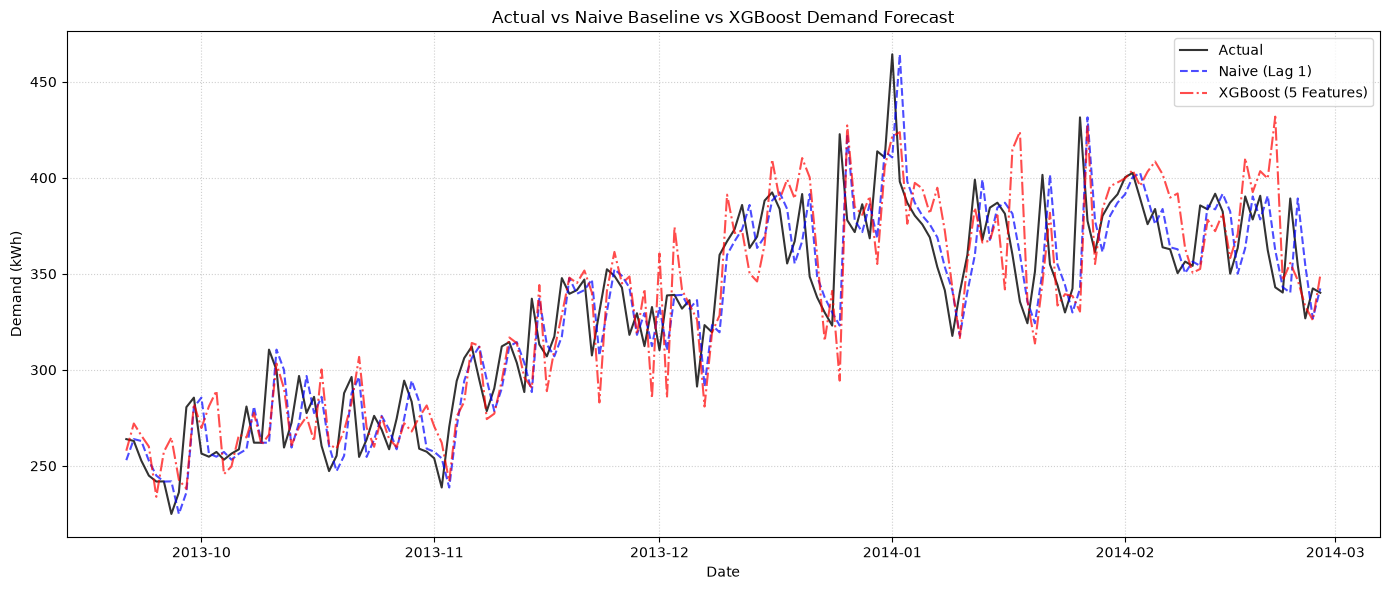

In [432]:
# 4. Plot all three across the test period
plt.figure(figsize=(14, 6))
plt.plot(df_comp.index, df_comp["actual"], label="Actual", alpha=0.8, color="black")
plt.plot(
    df_comp.index,
    df_comp["naive"],
    label="Naive (Lag 1)",
    linestyle="--",
    alpha=0.7,
    color="blue",
)
plt.plot(
    df_comp.index,
    df_comp["xgboost"],
    label="XGBoost (5 Features)",
    linestyle="-.",
    alpha=0.7,
    color="red",
)

plt.title("Actual vs Naive Baseline vs XGBoost Demand Forecast")
plt.xlabel("Date")
plt.ylabel("Demand (kWh)")
plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()

In [433]:
df_comp.head()

,actual,naive,xgboost
date,,,
2013-09-21,263.927,252.963,257.886200
2013-09-22,262.952,263.927,272.057739
2013-09-23,252.694,262.952,265.794281
2013-09-24,244.918,252.694,260.066864
2013-09-25,241.826,244.918,233.876419


In [434]:
print(df_comp.index.name)
print(df_comp.columns)

date
Index(['actual', 'naive', 'xgboost'], dtype='str')


In [435]:
print("Naive mean error:", (df_comp["actual"] - df_comp["naive"]).mean())
print("XGBoost mean error:", (df_comp["actual"] - df_comp["xgboost"]).mean())

Naive mean error: 0.5448687531249998
XGBoost mean error: -2.229235564504395


In [436]:
# Naive absolute error is stored in the error-analysis dataframe, not in df_comp
# print("Naive Absolute mean error:", df_errors["absolute_error"].mean())

# Add XGBoost absolute error to the comparison dataframe before averaging
df_comp["absolute_error_xgb"] = (df_comp["actual"] - df_comp["xgboost"]).abs()
df_comp["absolute_error_naive"] = (df_comp["actual"] - df_comp["naive"]).abs()
print("Naive Absolute mean error:", df_comp["absolute_error_naive"].mean())
print("XGBoost Absolute mean error:", (df_comp["absolute_error_xgb"]).mean())


Naive Absolute mean error: 18.035143793125002
XGBoost Absolute mean error: 21.298976614621587


 So:

Positive mean error → model tends to underpredict

Negative mean error → model tends to overpredict

In [437]:
baseline_pred = x_test["lag_7"]

from sklearn.metrics import mean_absolute_error
baseline_mae = mean_absolute_error(y_test,baseline_pred)

baseline_mae

print("Baseline MAE:", baseline_mae)

Baseline MAE: 27.660681216249998


In [438]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Assuming df_comp contains actual values and lag_7 predictions for the test period
seasonal_naive_pred = x_test.loc[y_test.index, "lag_7"].to_numpy()
actuals = df_comp["actual"]

mae_seasonal = mean_absolute_error(actuals, seasonal_naive_pred)
rmse_seasonal = np.sqrt(mean_squared_error(actuals, seasonal_naive_pred))

print(f"Seasonal Naive MAE: {mae_seasonal:.4f}")
print(f"Seasonal Naive RMSE: {rmse_seasonal:.4f}")

Seasonal Naive MAE: 27.6607
Seasonal Naive RMSE: 35.0161


lag_1 is currently the strongest of the three approaches.

Your EDA showed strong weekly correlation (lag_7 = 0.9158), but that does not mean lag_7 is a better forecasting rule than lag_1. The comparison demonstrates exactly why correlation and predictive performance aren't the same thing.

## important experiment to do before locking the model:

combine yesterday's demand with the weekly history, rather than choosing one or the other.

### For example, a simple ensemble baseline:

prediction = average of lag_1 and lag_7

This is still a transparent, deterministic baseline and gives us a fair test of whether the weekly signal adds value to yesterday's signal.

Next task: calculate predictions as:

( lag_1 + lag_7 ) / 2

on X_test, then calculate its MAE and RMSE.

In [439]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Combine lag_1 and lag_7 predictions
ensemble_pred = (x_test["lag_1"] + x_test["lag_7"]) / 2
actuals = df_comp["actual"]

# Calculate MAE and RMSE
mae_ensemble = mean_absolute_error(actuals, ensemble_pred)
rmse_ensemble = np.sqrt(mean_squared_error(actuals, ensemble_pred))

print(f"Ensemble MAE: {mae_ensemble:.4f}")
print(f"Ensemble RMSE: {rmse_ensemble:.4f}")

Ensemble MAE: 19.5456
Ensemble RMSE: 24.9591


Lag-1 baseline: MAE 18.0351 / RMSE 24.1867
Lag-7 baseline: MAE 27.6607 / RMSE 35.0161
Lag-1 + lag-7 ensemble: MAE 19.5456 / RMSE 24.9591
XGBoost: worse than the simple lag-1 baseline
## Step 1 — Do the 7-day moving-average baseline

This is the next thing I want you to do.

Why?

We want to answer:

Is a smoothed recent-history forecast better than simply saying "tomorrow will look like today"?

Use:

7-day moving average
= average of the previous 7 days

7-day moving average
= average of the previous 7 days

In [440]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

for i in range(1, 8):
    model_df[f"lag_{i}"] = model_df["daily_kwh"].shift(i)

# Combine lag_1 and lag_7 predictions
lag_columns = [f"lag_{i}" for i in range(1, 8)]

seven_day_ensemble_pred = (
    model_df.loc[y_test.index, lag_columns]
    .mean(axis=1)
)

actuals = df_comp["actual"]

# Calculate MAE and RMSE
mae_ma7 = mean_absolute_error(actuals,seven_day_ensemble_pred )
rmse_ma7 = np.sqrt(mean_squared_error(actuals, seven_day_ensemble_pred ))

print(f"7-Day Moving Average MAE: {mae_ma7:.4f}")
print(f"7-Day Moving Average RMSE: {rmse_ma7:.4f}")

7-Day Moving Average MAE: 19.8721
7-Day Moving Average RMSE: 24.8449


Your simplest baseline, yesterday's demand (lag_1), currently has the lowest MAE and RMSE among the tested approaches.

That means:

For this dataset and this particular test period, the tested ML/ensemble approaches did not outperform the simple lag-1 forecasting baseline.

05_modeling.ipynb

Model experiments
      ↓
✅ Baseline comparison
      ↓
👉 Final comparison table
      ↓
👉 % improvement vs baseline
      ↓
👉 Error analysis by month / demand level
      ↓
👉 Validate forecasting approach

In [ ]:
import pandas as pd
 # 1. Create the comparison dataframe
results_data = {
    "Model": [
        "Lag-1 Naive",
        "Lag-1 + Lag-7 Ensemble",
        "7-Day Moving Average",
        "XGBoost (5 features)",
        "Seasonal Naive (Lag-7)",
    ],

    "MAE": [18.0351, 19.5456, 19.8721, 21.2990, 27.6607],
    
    "RMSE": [24.1867, 24.9591, 24.8449, 28.8871, 35.0161],
}
df_result = pd.DataFrame(results_data)

# df_errors["error"] = df_errors["actual"] - df_errors["naive_prediction"]
# df_errors["absolute_error"] = df_errors["error"].abs()

# top_10_error = (
#     df_errors
#     .sort_values(by="absolute_error", ascending=False)
#     .head(10)
# )

Calculate improvement vs baseline

For every alternative model, calculate percentage change relative to the lag-1 baseline.

The formula is:
(({Baseline MAE} - {Model MAE}) / {Baseline MAE} )*100

Positive = improvement.
Negative = worse than baseline.

This will make the conclusion quantitative rather than subjective.

In [ ]:
# 2. Calculate percentage degradation/improvement relative to Lag-1 Naive baseline
baseline_mae = 18.0351
baseline_rmse = 24.1867

df_result["MAE % vs baseline"] = ((baseline_mae - df_result["MAE"])/baseline_mae)*100

df_result["RMSE % vs Baseline"] = (
    (baseline_rmse - df_result["RMSE"]) / baseline_rmse
) * 100


print(df_result.to_string(index=False))



Forecasting model error comparison

Lower MAE indicates smaller average absolute forecasting error on the same test period.

### The key conclusion is:

The lag-1 naive baseline outperformed every alternative tested on this test period.

And your percentage table makes that especially clear:

Ensemble: 8.38% worse MAE

7-day moving average: 10.19% worse

XGBoost: 18.10% worse

Seasonal naive: 53.37% worse

## Error Analysis phase by calculating the monthly breakdown of absolute error for your lag-1 naive model on the test set.

analyze naive-model absolute error by month

mean (which gives  the monthly MAE) and the count (number of test observations per month):

In [ ]:
df_comp["absolute_error_naive"] = (df_comp["actual"] - df_comp["naive"]).abs()
df_comp["month"]=df_comp.index.month
# Group by month to calculate MAE and count of test observations
monthly_error = (df_comp.groupby("month")["absolute_error_naive"].agg(MAE="mean", Count="count")
    .reset_index())
monthly_error

What we can conclude

There is some variation in forecast error across months:

September has the lowest observed MAE here: 11.0690 kWh
January has the highest: 24.0673 kWh
December is also relatively high: 20.4655 kWh
October–November are around 15.8–16.3 kWh

But there's an important limitation: your test period only covers September 2013 through February 2014, so this is not a full-year seasonal comparison.